# XGBoost vs Random Forest — Predicción Productividad (t/h)

Compara dos modelos de ensamble para predecir `productividad_t_h` (t/h real).

| Capa | Archivo | Filas | Descripción |
|------|---------|-------|-------------|
| Gold | `data/gold/laminacion.parquet` | 1 183 | Sin nulos, features listas para modelo |

**Índice**
1. Carga y codificación
2. EDA — target, distribución, correlaciones
3. Definición de features
4. Entrenamiento XGBoost + Random Forest
5. Validación cruzada (5-fold)
6. Comparación de métricas
7. Real vs Predicho
8. Curvas de aprendizaje
9. Importancia de features (impurity)
10. Importancia por permutación
11. SHAP — XGBoost
12. SHAP — Random Forest
13. Error por producto
14. Modelo de planificación (sin paradas)

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (train_test_split, KFold,
                                      cross_val_score, learning_curve)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

GOLD_PATH = Path('../data/gold/laminacion.parquet')
TARGET    = 'productividad_t_h'
SEED      = 42
CV_FOLDS  = 5

# Colores fijos por modelo
C_XGB = '#1f77b4'   # azul
C_RF  = '#ff7f0e'   # naranja

## 1. Carga y codificación

In [ ]:
df = pd.read_parquet(GOLD_PATH)

le_producto = LabelEncoder()
df['producto_cod'] = le_producto.fit_transform(df['producto'])

# El setup es el tiempo de transición entre familias de materiales: ocurre una
# sola vez, DESPUÉS de la última orden de la familia saliente (ej: tras el último
# 8mm antes de pasar a 3/8"). En el Excel el valor aparece en una fila aleatoria
# del grupo; lo movemos a la ÚLTIMA fila para que el modelo aprenda la posición
# correcta del evento.
def _setup_to_last(x):
    total = x.sum()
    result = pd.Series(0.0, index=x.index)
    if total > 0:
        result.iloc[-1] = total   # última orden de la familia saliente
    return result

df['paradas_setup_h'] = df.groupby(
    ['producto', 'mes_num', 'tipo_cod']
)['paradas_setup_h'].transform(_setup_to_last)
df['paradas_total_h']     = df['paradas_setup_h'] + df['paradas_imprev_h']
df['tiempo_productivo_h'] = (df['tiempo_lam_h'] - df['paradas_total_h']).clip(lower=0)

print(f"Shape: {df.shape}")
print(f"Productos ({len(le_producto.classes_)}): {list(le_producto.classes_)}")
print(f"\nTarget — {TARGET}:")
print(df[TARGET].describe().round(2))
df.head()

## 2. EDA

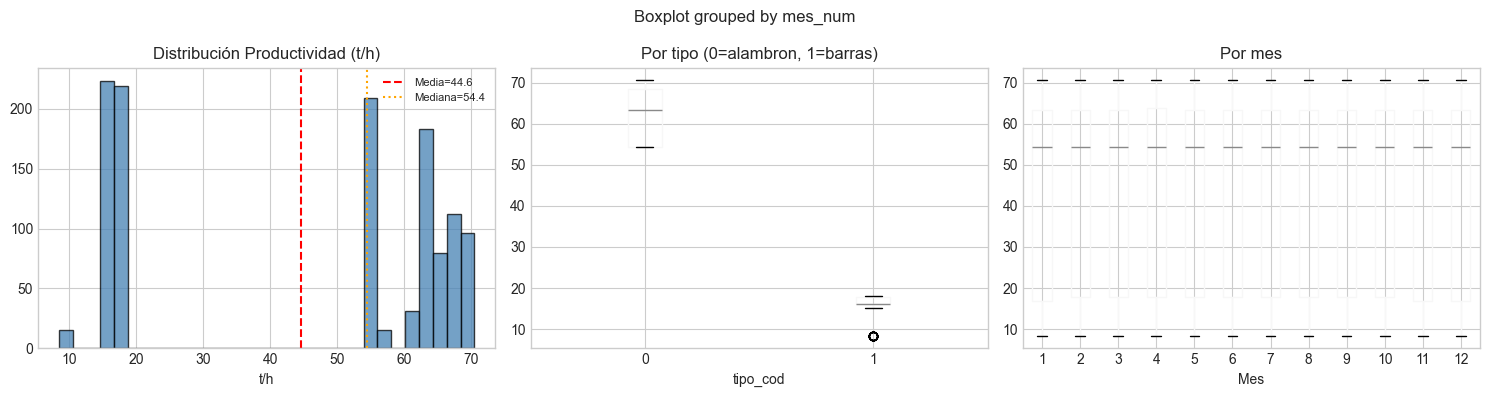

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df[TARGET], bins=30, edgecolor='k', alpha=0.75, color='steelblue')
axes[0].axvline(df[TARGET].mean(),   color='red',    linestyle='--',
                label=f'Media={df[TARGET].mean():.1f}')
axes[0].axvline(df[TARGET].median(), color='orange', linestyle=':',
                label=f'Mediana={df[TARGET].median():.1f}')
axes[0].set_title('Distribución Productividad (t/h)')
axes[0].set_xlabel('t/h'); axes[0].legend(fontsize=8)

df.boxplot(column=TARGET, by='tipo_cod', ax=axes[1])
plt.sca(axes[1]); plt.title('Por tipo (0=alambron, 1=barras)')
axes[1].set_xlabel('tipo_cod')

df.boxplot(column=TARGET, by='mes_num', ax=axes[2])
plt.sca(axes[2]); plt.title('Por mes')
axes[2].set_xlabel('Mes')

plt.tight_layout(); plt.show()

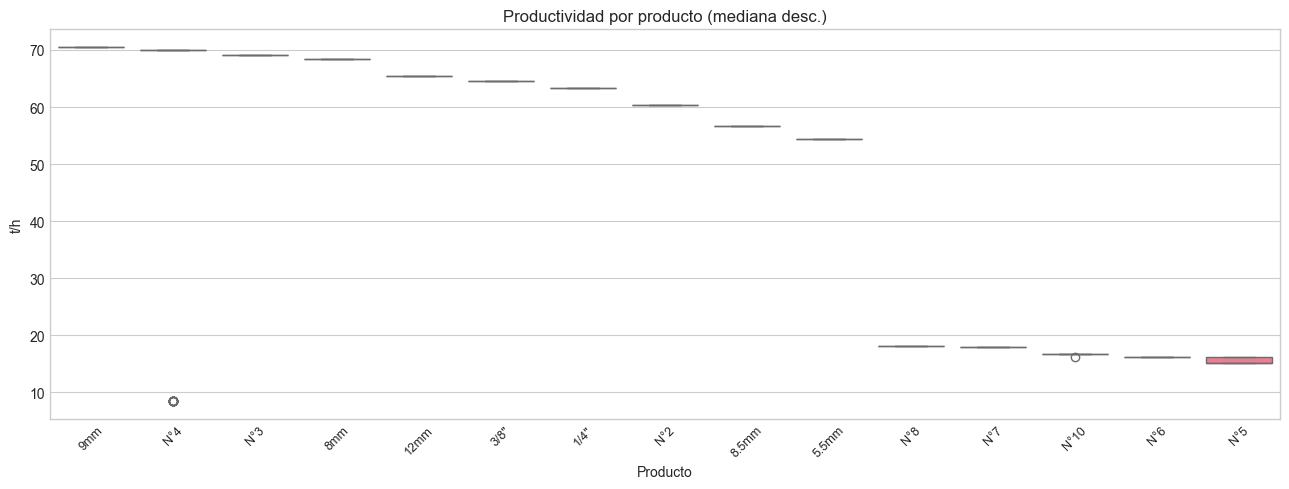

                   median   std  count
tipo_cod producto                     
0        1/4"       63.41  0.00    183
         12mm       65.47  0.00     16
         3/8"       64.63  0.00     64
         5.5mm      54.43  0.00    209
         8.5mm      56.74  0.00     15
         8mm        68.38  0.00    112
         9mm        70.50  0.00     16
         N°2        60.30  0.00     31
         N°3        69.11  0.00     33
         N°4        69.99  0.00     47
1        N°10       16.80  0.08     57
         N°4         8.42  0.00     15
         N°5        15.09  0.49    112
         N°6        16.13  0.00    110
         N°7        17.85  0.00     80
         N°8        18.07  0.00     83


In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))
orden = df.groupby('producto')[TARGET].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='producto', y=TARGET, order=orden, ax=ax)
ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.sca(ax); plt.title('Productividad por producto (mediana desc.)')
ax.set_xlabel('Producto'); ax.set_ylabel('t/h')
plt.tight_layout(); plt.show()

print(df.groupby(['tipo_cod', 'producto'])[TARGET]
        .agg(['median', 'std', 'count']).round(2))

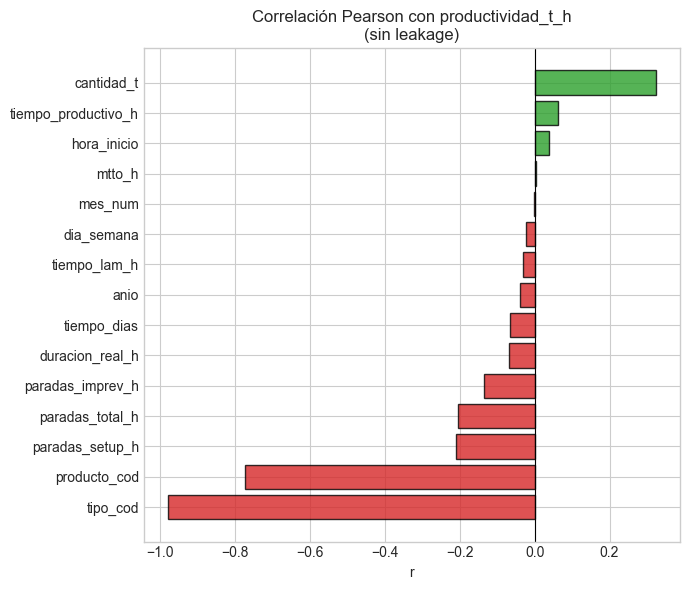

In [ ]:
# Columnas con leakage confirmado (prod_teorica_t_h == productividad_t_h exacto)
LEAK_COLS = ['prod_teorica_t_h', 'cap_teorica_t_h', 'prod_bruta_t_h',
             'prod_real_t_dia', 't_dia', 'eficiencia', 'rendimiento',
             'iu_teorico', 'iu', 'delta_iu', 'producto']

corr_cols = [c for c in df.select_dtypes(include=np.number).columns
             if c not in LEAK_COLS and c != TARGET]
corr = df[corr_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(corr.index, corr.values,
        color=['#d62728' if v < 0 else '#2ca02c' for v in corr],
        edgecolor='k', alpha=0.8)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_title('Correlación Pearson con productividad_t_h\n(sin leakage)')
ax.set_xlabel('r')
plt.tight_layout(); plt.show()

## 3. Definición de features

> **Leakage descartado:** `prod_teorica_t_h`, `cap_teorica_t_h`, `prod_bruta_t_h`, `prod_real_t_dia` y `t_dia` provienen de la tabla de parámetros del Excel, que almacena los **promedios reales del mes** como valores "teóricos" → correlación perfecta (r = 1.0) con el target. Se excluyen del modelo.

In [ ]:
# Conocidas antes de iniciar la orden
FEATURES_PLAN = [
    'tipo_cod',       # alambron=0 / barras=1
    'producto_cod',   # diámetro o número codificado
    'mes_num',        # 1–12
    'anio',
    'hora_inicio',    # hora del turno
    'dia_semana',     # lunes=0 … domingo=6
    # 'tiempo_lam_h' ELIMINADO: = cantidad_t / productividad_t_h → leakage no-lineal
    'cantidad_t',     # toneladas programadas
    'mtto_h',         # mantenimiento por familia (esporádico, modelo aprende cuándo)
]

# Observadas durante / después de la orden  (sin derivadas de tiempo_lam_h)
FEATURES_EJEC = [
    'paradas_setup_h',   # parada de transición entre familias (evento único ✓)
    'paradas_imprev_h',  # paradas imprevistas
    'paradas_total_h',   # suma de los anteriores
    # 'tiempo_productivo_h' ELIMINADO: = tiempo_lam_h − paradas  (leakage)
    # 'duracion_real_h'     ELIMINADO: ≈ tiempo_lam_h + paradas  (leakage)
]

FEATURES_ALL = FEATURES_PLAN + FEATURES_EJEC

print(f"Planificación ({len(FEATURES_PLAN)}): {FEATURES_PLAN}")
print(f"Ejecución     ({len(FEATURES_EJEC)}): {FEATURES_EJEC}")
print(f"Total         : {len(FEATURES_ALL)}")

X = df[FEATURES_ALL]
y = df[TARGET]

# Split temporal: entrenamos con 2025 y evaluamos con 2026.
# El split 80/20 aleatorio ponía filas del mismo grupo (producto × mes × tipo)
# en train y test → productividad constante por grupo → R²=1.0 por memorización.
# El split por año obliga al modelo a GENERALIZAR a meses no vistos.
train_mask = df['anio'] == 2025
test_mask  = df['anio'] == 2026
X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]
print(f"\nTrain (2025): {len(X_train)}  Test (2026): {len(X_test)}")

## 4. Entrenamiento

In [ ]:

# ── XGBoost ──────────────────────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators     = 400,
    max_depth        = 6,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    random_state     = SEED,
    verbosity        = 0,
    n_jobs           = -1,
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)], verbose=False)
print("XGBoost entrenado ✓")

# ── Random Forest ─────────────────────────────────────────────────────────────
# max_features=None → usa todas las features (default sklearn regresión)
# Genera árboles profundos que capturan la estructura determinista tipo×producto
rf_model = RandomForestRegressor(
    n_estimators    = 300,
    min_samples_leaf= 3,
    oob_score       = True,
    random_state    = SEED,
    n_jobs          = -1,
)
rf_model.fit(X_train, y_train)
print(f"Random Forest entrenado ✓  (OOB R²={rf_model.oob_score_:.4f})")


XGBoost entrenado ✓
Random Forest entrenado ✓  (OOB R²=1.0000)


## 5. Validación cruzada 5-fold

Ejecutando CV...
CV completado.
               R²  media  R²  std  RMSE media  RMSE std  MAE  media
Modelo                                                             
XGBoost           0.9997   0.0001      0.3579    0.0886      0.1390
Random Forest     1.0000   0.0000      0.0461    0.0109      0.0128


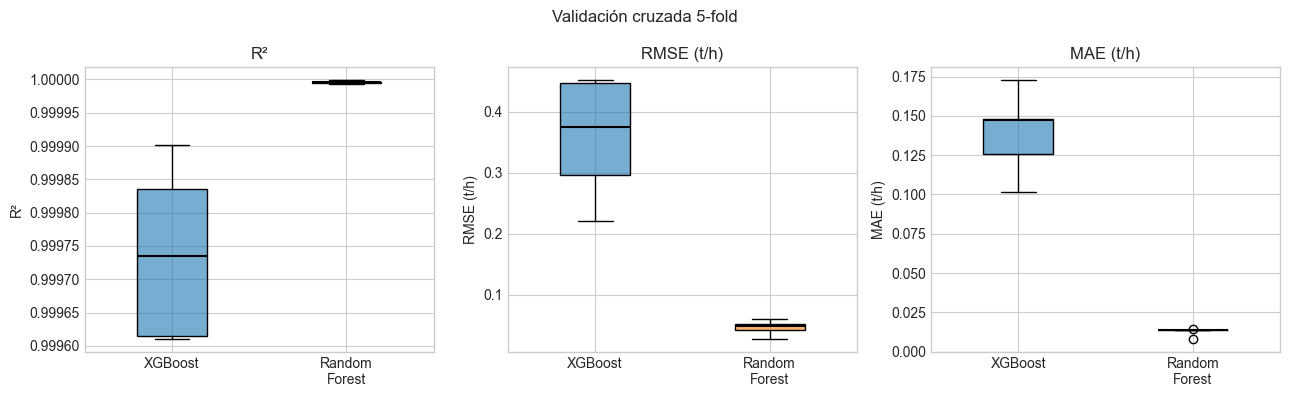

In [ ]:
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

def cv_metrics(estimator, X, y, cv):
    r2_scores   = cross_val_score(estimator, X, y, cv=cv, scoring='r2', n_jobs=-1)
    rmse_scores = np.sqrt(-cross_val_score(estimator, X, y, cv=cv,
                                           scoring='neg_mean_squared_error', n_jobs=-1))
    mae_scores  = -cross_val_score(estimator, X, y, cv=cv,
                                   scoring='neg_mean_absolute_error', n_jobs=-1)
    return r2_scores, rmse_scores, mae_scores

print("Ejecutando CV...")
r2_xgb,  rmse_xgb,  mae_xgb  = cv_metrics(xgb_model, X, y, kf)
r2_rf,   rmse_rf,   mae_rf   = cv_metrics(rf_model,  X, y, kf)
print("CV completado.")

# ── Resumen ──
cv_summary = pd.DataFrame({
    'Modelo': ['XGBoost', 'Random Forest'],
    'R²  media': [r2_xgb.mean(),   r2_rf.mean()],
    'R²  std':   [r2_xgb.std(),    r2_rf.std()],
    'RMSE media': [rmse_xgb.mean(), rmse_rf.mean()],
    'RMSE std':   [rmse_xgb.std(),  rmse_rf.std()],
    'MAE  media': [mae_xgb.mean(),  mae_rf.mean()],
}).set_index('Modelo').round(4)
print(cv_summary)

# ── Box plots de scores por fold ──
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, vals_x, vals_r, ylabel in zip(
    axes,
    ['R²', 'RMSE (t/h)', 'MAE (t/h)'],
    [r2_xgb, rmse_xgb, mae_xgb],
    [r2_rf,  rmse_rf,  mae_rf],
    ['R²', 'RMSE (t/h)', 'MAE (t/h)'],
):
    bp = ax.boxplot([vals_x, vals_r], labels=['XGBoost', 'Random\nForest'],
                    patch_artist=True, widths=0.4)
    bp['boxes'][0].set_facecolor(C_XGB + '99')
    bp['boxes'][1].set_facecolor(C_RF  + '99')
    for median in bp['medians']:
        median.set_color('black'); median.set_linewidth(1.5)
    ax.set_title(metric); ax.set_ylabel(ylabel)

plt.suptitle(f'Validación cruzada {CV_FOLDS}-fold', fontsize=12)
plt.tight_layout(); plt.show()

## 6. Comparación de métricas (hold-out)

               RMSE (t/h)  MAE  (t/h)      R²
XGBoost            0.5557      0.1799  0.9994
Random Forest      0.0498      0.0141  1.0000


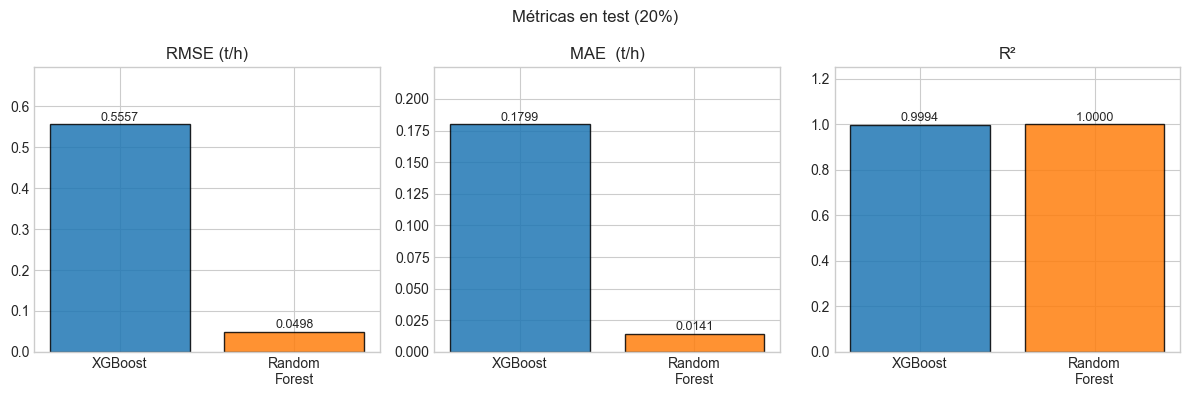

In [ ]:
yp_xgb = xgb_model.predict(X_test)
yp_rf  = rf_model.predict(X_test)

metricas = pd.DataFrame({
    'RMSE (t/h)': [np.sqrt(mean_squared_error(y_test, yp_xgb)),
                   np.sqrt(mean_squared_error(y_test, yp_rf))],
    'MAE  (t/h)': [mean_absolute_error(y_test, yp_xgb),
                   mean_absolute_error(y_test, yp_rf)],
    'R²':         [r2_score(y_test, yp_xgb),
                   r2_score(y_test, yp_rf)],
}, index=['XGBoost', 'Random Forest']).round(4)
print(metricas)

# Gráfica comparativa de métricas
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, mejor in zip(axes,
                           ['RMSE (t/h)', 'MAE  (t/h)', 'R²'],
                           ['min', 'min', 'max']):
    vals = metricas[col].values
    bars = ax.bar(['XGBoost', 'Random\nForest'], vals,
                  color=[C_XGB, C_RF], edgecolor='k', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(col); ax.set_ylim(0, vals.max() * 1.25)

plt.suptitle('Métricas en test (20%)', fontsize=12)
plt.tight_layout(); plt.show()

## 7. Real vs Predicho

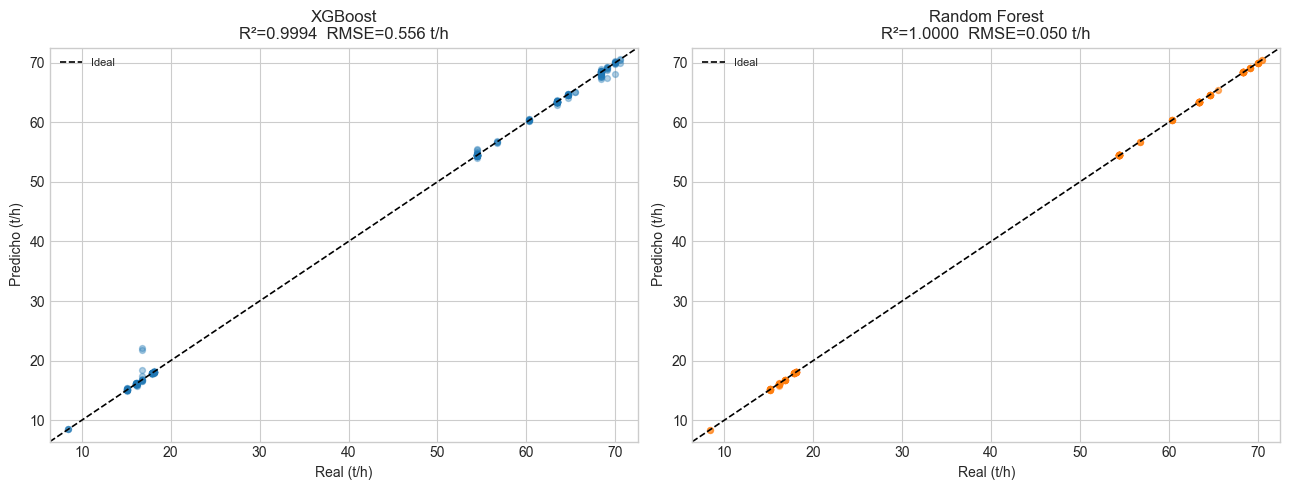

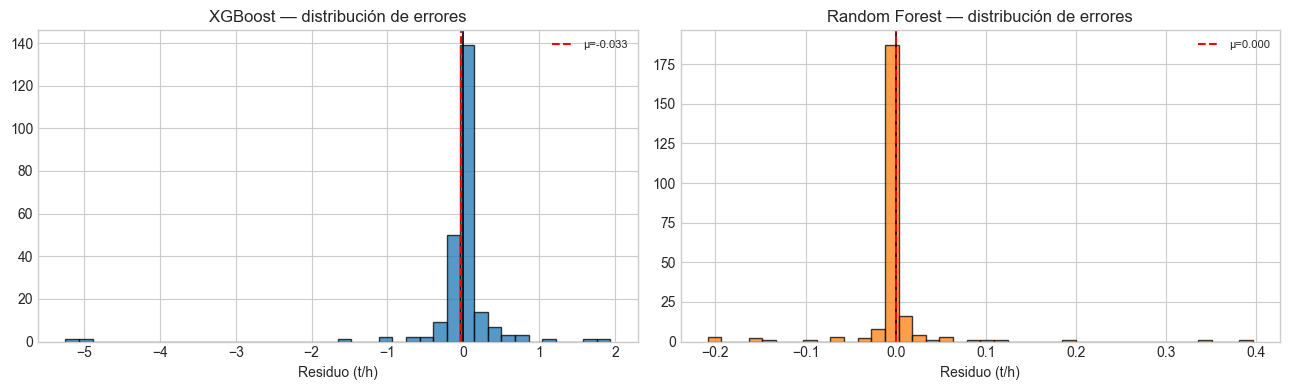

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lim = [y_test.min() - 2, y_test.max() + 2]

for ax, yp, label, color in [
    (axes[0], yp_xgb, 'XGBoost', C_XGB),
    (axes[1], yp_rf,  'Random Forest', C_RF),
]:
    r2 = r2_score(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    ax.scatter(y_test, yp, alpha=0.35, s=18, color=color)
    ax.plot(lim, lim, 'k--', linewidth=1.2, label='Ideal')
    ax.set_xlabel('Real (t/h)'); ax.set_ylabel('Predicho (t/h)')
    ax.set_title(f'{label}\nR²={r2:.4f}  RMSE={rmse:.3f} t/h')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# Distribución de residuos
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, yp, label, color in [
    (axes[0], yp_xgb, 'XGBoost', C_XGB),
    (axes[1], yp_rf,  'Random Forest', C_RF),
]:
    res = y_test.values - yp
    ax.hist(res, bins=40, color=color, edgecolor='k', alpha=0.75)
    ax.axvline(0, color='k', linewidth=1.2)
    ax.axvline(res.mean(), color='red', linestyle='--',
               label=f'μ={res.mean():.3f}')
    ax.set_title(f'{label} — distribución de errores')
    ax.set_xlabel('Residuo (t/h)'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

## 8. Curvas de aprendizaje

RMSE de entrenamiento y validación a medida que crece el tamaño del conjunto de entrenamiento.

Calculando curvas de aprendizaje...
Listo.


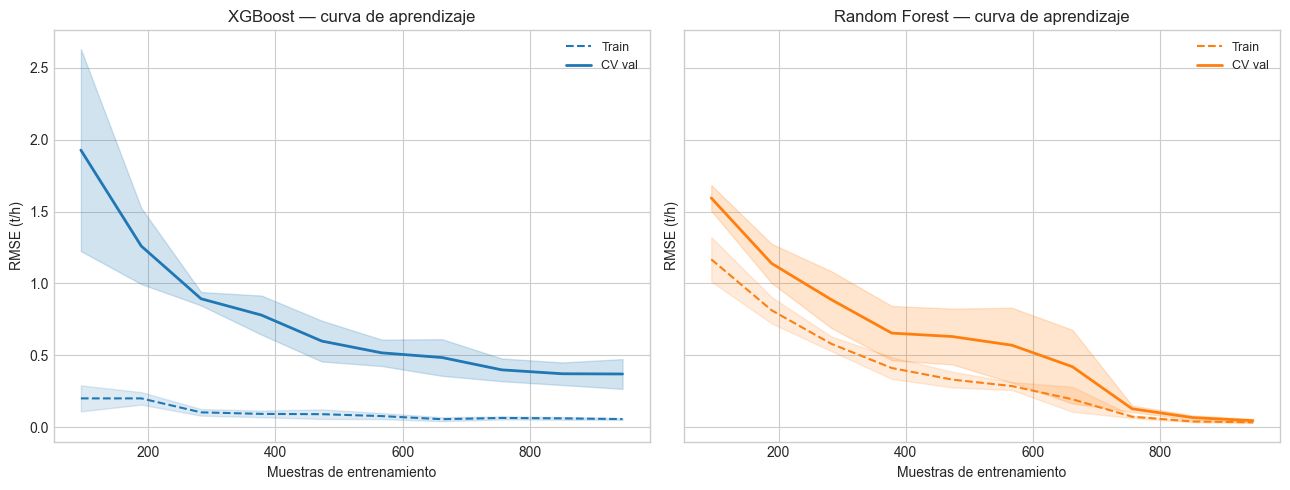

In [ ]:
train_sizes = np.linspace(0.1, 1.0, 10)

def lc_rmse(estimator, X, y, sizes, cv):
    ts, tr_s, val_s = learning_curve(
        estimator, X, y,
        train_sizes=sizes,
        cv=cv,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
    )
    return ts, np.sqrt(-tr_s), np.sqrt(-val_s)

kf5 = KFold(n_splits=5, shuffle=True, random_state=SEED)
print("Calculando curvas de aprendizaje...")
ts_x, tr_x, val_x = lc_rmse(xgb_model, X, y, train_sizes, kf5)
ts_r, tr_r, val_r = lc_rmse(rf_model,  X, y, train_sizes, kf5)
print("Listo.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, ts, tr, val, label, color in [
    (axes[0], ts_x, tr_x, val_x, 'XGBoost',       C_XGB),
    (axes[1], ts_r, tr_r, val_r, 'Random Forest',  C_RF),
]:
    ax.plot(ts, tr.mean(axis=1),  '--', color=color, label='Train')
    ax.fill_between(ts, tr.mean(1)-tr.std(1),  tr.mean(1)+tr.std(1),
                    alpha=0.15, color=color)
    ax.plot(ts, val.mean(axis=1), '-',  color=color, label='CV val', linewidth=2)
    ax.fill_between(ts, val.mean(1)-val.std(1), val.mean(1)+val.std(1),
                    alpha=0.2, color=color)
    ax.set_title(f'{label} — curva de aprendizaje')
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('RMSE (t/h)')
    ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

## 9. Importancia de features — impurity (F-score / Gini)

Basada en la reducción de impureza durante el entrenamiento.

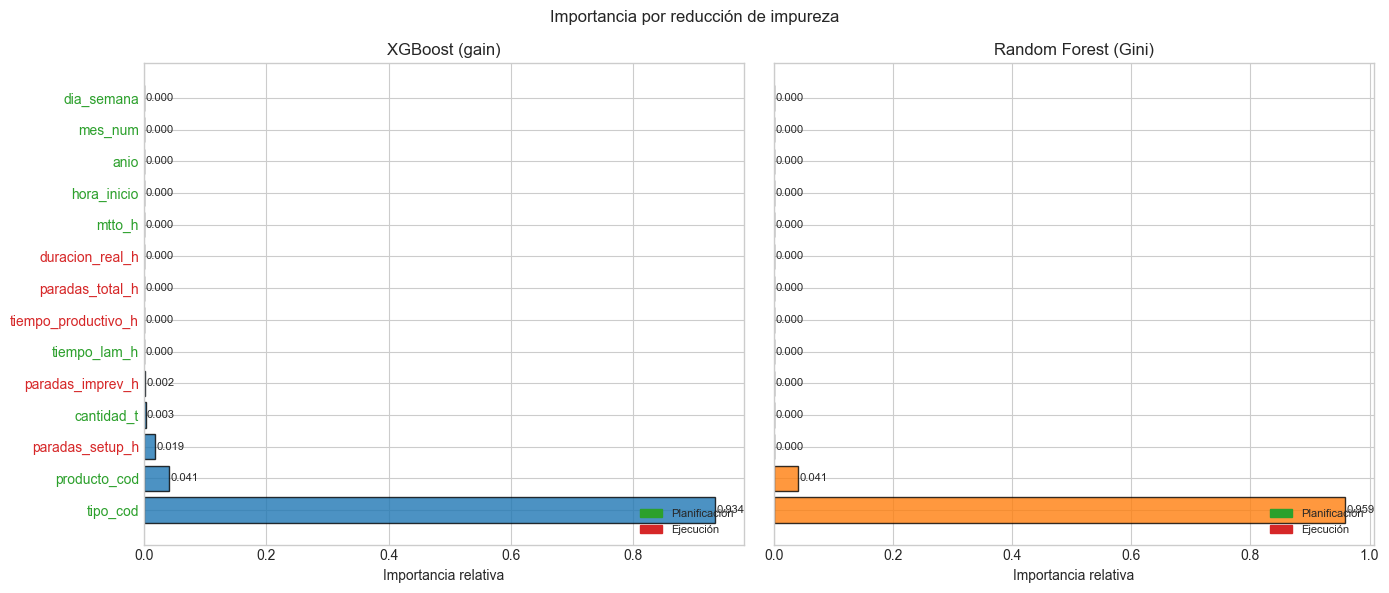

In [ ]:
imp_xgb = pd.Series(dict(zip(FEATURES_ALL, xgb_model.feature_importances_)))
imp_rf  = pd.Series(dict(zip(FEATURES_ALL, rf_model.feature_importances_)))

orden = imp_xgb.sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, imp, label, color in [
    (axes[0], imp_xgb, 'XGBoost (gain)',       C_XGB),
    (axes[1], imp_rf,  'Random Forest (Gini)',  C_RF),
]:
    vals = imp[orden]
    bars = ax.barh(orden, vals, color=color, edgecolor='k', alpha=0.8)
    for bar, v in zip(bars, vals):
        ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=8)
    ax.set_title(label)
    ax.set_xlabel('Importancia relativa')

# Colorear por grupo (planificación / ejecución)
for ax in axes:
    for tick_label in ax.get_yticklabels():
        tick_label.set_color('#2ca02c' if tick_label.get_text() in FEATURES_PLAN
                             else '#d62728')
    ax.legend(handles=[
        Patch(color='#2ca02c', label='Planificación'),
        Patch(color='#d62728', label='Ejecución'),
    ], loc='lower right', fontsize=8)

plt.suptitle('Importancia por reducción de impureza', fontsize=12)
plt.tight_layout(); plt.show()

## 10. Importancia por permutación

Más robusta: mide cuánto sube el error al mezclar aleatoriamente cada feature.

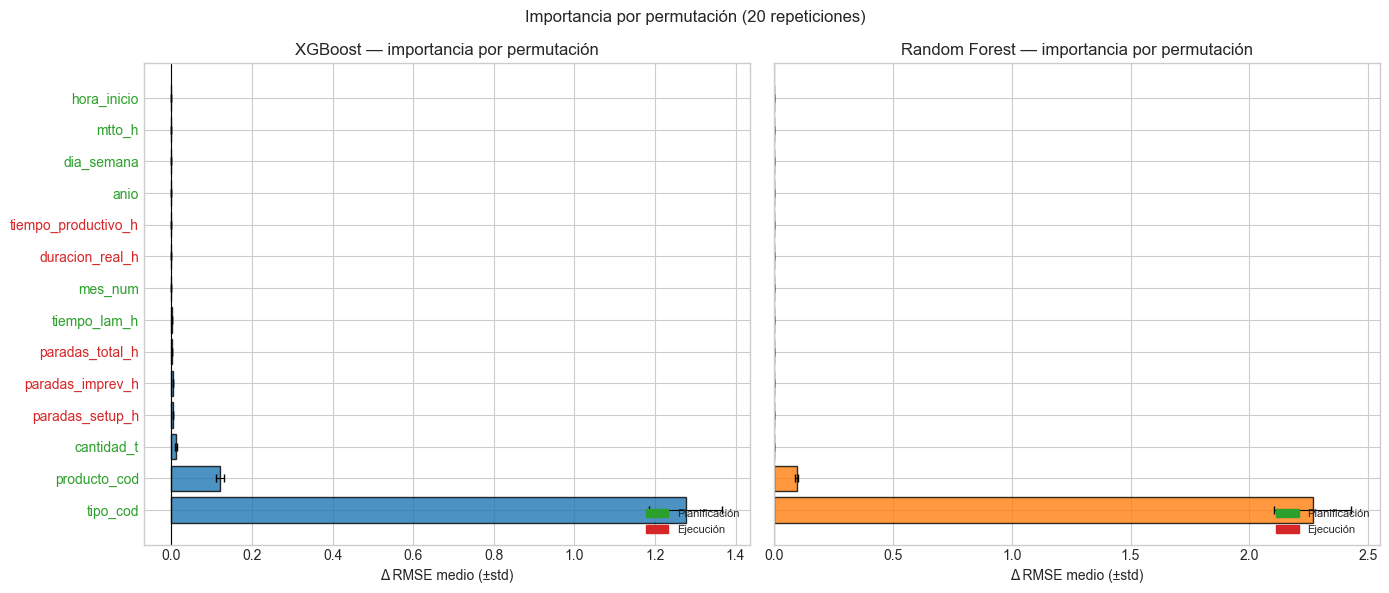

In [ ]:
pi_xgb = permutation_importance(xgb_model, X_test, y_test,
                                  n_repeats=20, random_state=SEED, n_jobs=-1)
pi_rf  = permutation_importance(rf_model,  X_test, y_test,
                                  n_repeats=20, random_state=SEED, n_jobs=-1)

pi_xgb_s = pd.Series(pi_xgb.importances_mean, index=FEATURES_ALL)
pi_rf_s  = pd.Series(pi_rf.importances_mean,  index=FEATURES_ALL)

orden_pi = pi_xgb_s.sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, pi, label, color in [
    (axes[0], pi_xgb, 'XGBoost',      C_XGB),
    (axes[1], pi_rf,  'Random Forest', C_RF),
]:
    pass
    # Construir dict en orden correcto
    ordered_means = pd.Series(
        {f: pi.importances_mean[i] for i, f in enumerate(FEATURES_ALL)}
    )[orden_pi]
    ordered_stds = pd.Series(
        {f: pi.importances_std[i] for i, f in enumerate(FEATURES_ALL)}
    )[orden_pi]

    ax.barh(orden_pi, ordered_means, xerr=ordered_stds,
            color=color, edgecolor='k', alpha=0.8,
            error_kw=dict(elinewidth=0.8, capsize=3))
    ax.axvline(0, color='k', linewidth=0.8)
    ax.set_title(f'{label} — importancia por permutación')
    ax.set_xlabel('Δ RMSE medio (±std)')

for ax in axes:
    for tick_label in ax.get_yticklabels():
        tick_label.set_color('#2ca02c' if tick_label.get_text() in FEATURES_PLAN
                             else '#d62728')
    ax.legend(handles=[
        Patch(color='#2ca02c', label='Planificación'),
        Patch(color='#d62728', label='Ejecución'),
    ], loc='lower right', fontsize=8)

plt.suptitle('Importancia por permutación (20 repeticiones)', fontsize=12)
plt.tight_layout(); plt.show()

## 11. SHAP — XGBoost

SHAP (SHapley Additive exPlanations) mide la contribución de cada feature a cada predicción individual.

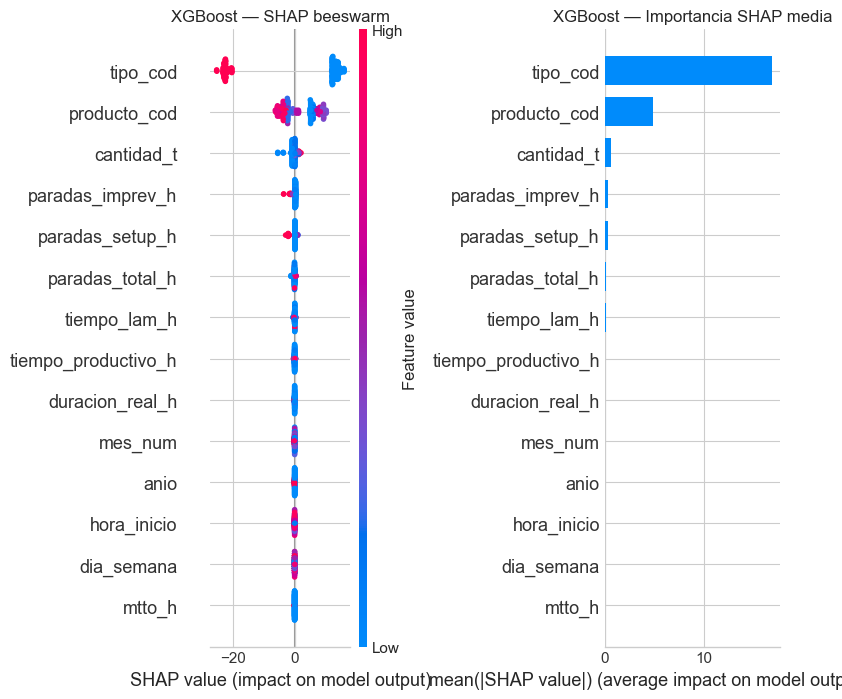

In [ ]:
explainer_xgb  = shap.TreeExplainer(xgb_model)
shap_vals_xgb  = explainer_xgb.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Beeswarm
plt.sca(axes[0])
shap.summary_plot(shap_vals_xgb, X_test,
                  feature_names=FEATURES_ALL,
                  plot_type='dot', show=False, max_display=14)
axes[0].set_title('XGBoost — SHAP beeswarm')

# Bar (importancia media |SHAP|)
plt.sca(axes[1])
shap.summary_plot(shap_vals_xgb, X_test,
                  feature_names=FEATURES_ALL,
                  plot_type='bar', show=False, max_display=14)
axes[1].set_title('XGBoost — Importancia SHAP media')

plt.tight_layout(); plt.show()

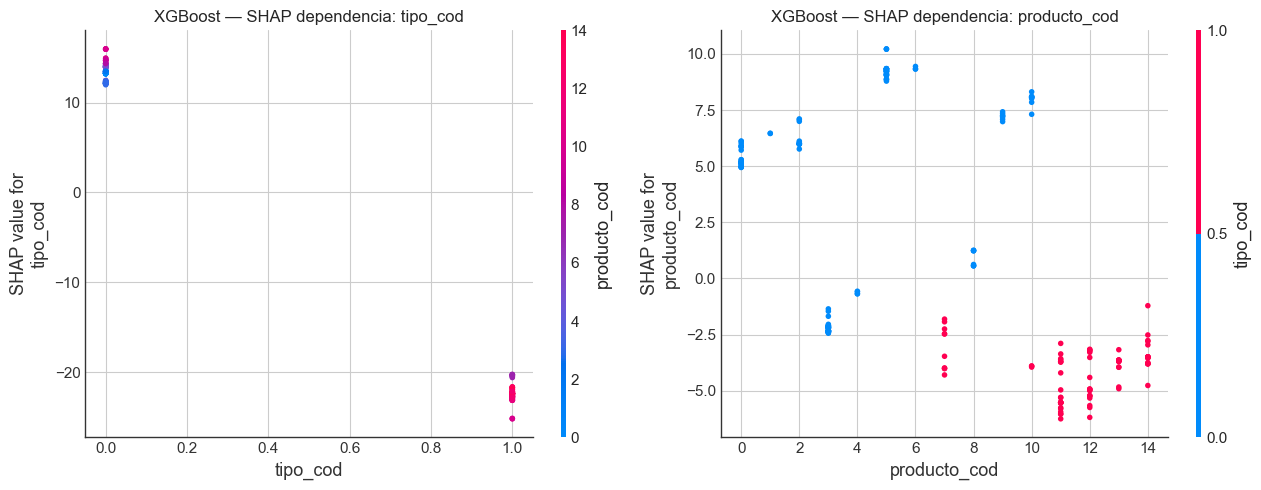

In [ ]:
# Dependencia: tipo_cod y producto_cod (dominantes)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, interact in [
    (axes[0], 'tipo_cod',     'producto_cod'),
    (axes[1], 'producto_cod', 'tipo_cod'),
]:
    shap.dependence_plot(feat, shap_vals_xgb, X_test,
                         interaction_index=interact,
                         feature_names=FEATURES_ALL,
                         ax=ax, show=False)
    ax.set_title(f'XGBoost — SHAP dependencia: {feat}')

plt.tight_layout(); plt.show()

## 12. SHAP — Random Forest

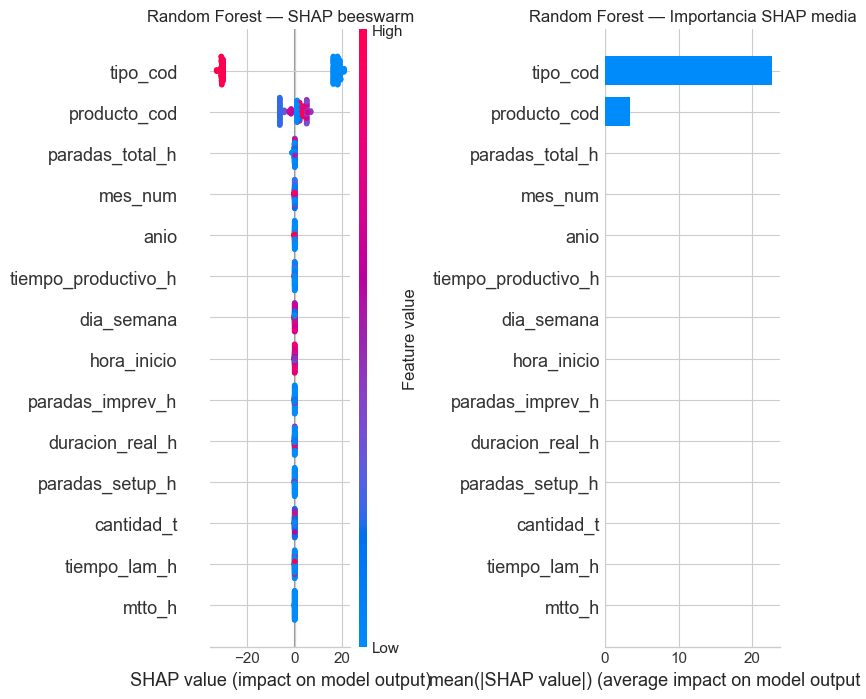

In [ ]:
explainer_rf  = shap.TreeExplainer(rf_model)
shap_vals_rf  = explainer_rf.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.sca(axes[0])
shap.summary_plot(shap_vals_rf, X_test,
                  feature_names=FEATURES_ALL,
                  plot_type='dot', show=False, max_display=14)
axes[0].set_title('Random Forest — SHAP beeswarm')

plt.sca(axes[1])
shap.summary_plot(shap_vals_rf, X_test,
                  feature_names=FEATURES_ALL,
                  plot_type='bar', show=False, max_display=14)
axes[1].set_title('Random Forest — Importancia SHAP media')

plt.tight_layout(); plt.show()

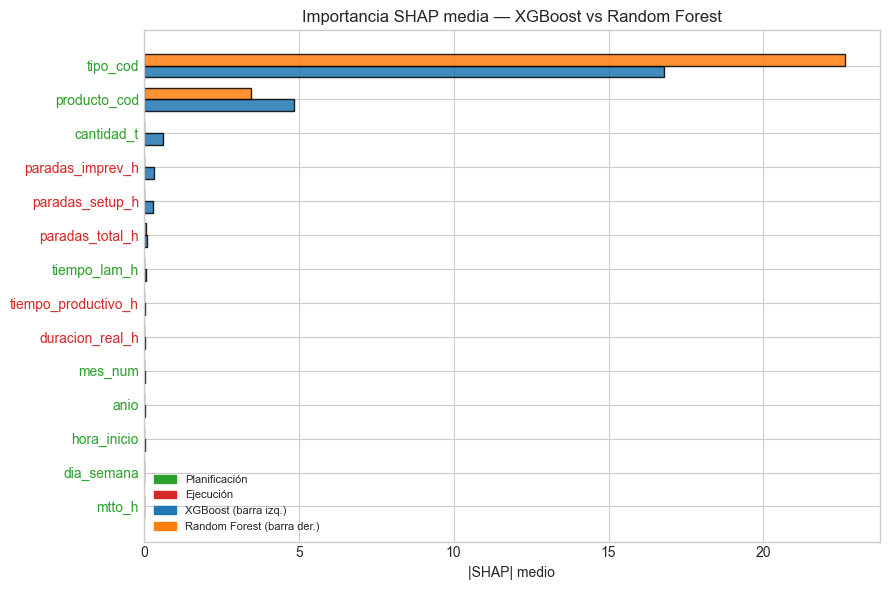

                     XGBoost  Random Forest
tipo_cod             16.7780        22.6323
producto_cod          4.8609         3.4575
cantidad_t            0.6196         0.0009
paradas_imprev_h      0.3131         0.0013
paradas_setup_h       0.3061         0.0009
paradas_total_h       0.0902         0.0805
tiempo_lam_h          0.0725         0.0004
tiempo_productivo_h   0.0499         0.0020
duracion_real_h       0.0358         0.0011
mes_num               0.0346         0.0185
anio                  0.0273         0.0163
hora_inicio           0.0238         0.0014
dia_semana            0.0113         0.0018
mtto_h                0.0030         0.0000


In [ ]:
# Comparación importancias SHAP absolutas: XGB vs RF
mean_abs_xgb = pd.Series(np.abs(shap_vals_xgb).mean(axis=0), index=FEATURES_ALL)
mean_abs_rf  = pd.Series(np.abs(shap_vals_rf ).mean(axis=0), index=FEATURES_ALL)

shap_cmp = pd.DataFrame({'XGBoost': mean_abs_xgb, 'Random Forest': mean_abs_rf})
shap_cmp = shap_cmp.sort_values('XGBoost', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
x = np.arange(len(shap_cmp))
w = 0.35
ax.barh(x - w/2, shap_cmp['XGBoost'],      w, label='XGBoost',      color=C_XGB, alpha=0.85, edgecolor='k')
ax.barh(x + w/2, shap_cmp['Random Forest'], w, label='Random Forest', color=C_RF,  alpha=0.85, edgecolor='k')
ax.set_yticks(x); ax.set_yticklabels(shap_cmp.index)
ax.set_xlabel('|SHAP| medio')
ax.set_title('Importancia SHAP media — XGBoost vs Random Forest')
ax.legend()

for tick_label in ax.get_yticklabels():
    tick_label.set_color('#2ca02c' if tick_label.get_text() in FEATURES_PLAN
                         else '#d62728')
ax.legend(handles=[
    Patch(color='#2ca02c', label='Planificación'),
    Patch(color='#d62728', label='Ejecución'),
    Patch(color=C_XGB,     label='XGBoost (barra izq.)'),
    Patch(color=C_RF,      label='Random Forest (barra der.)'),
], fontsize=8)

plt.tight_layout(); plt.show()
print(shap_cmp.sort_values('XGBoost', ascending=False).round(4))

## 13. Error por producto — comparación

                   MAE XGBoost  MAE RF
tipo     producto                     
barras   N°10            1.319   0.014
alambron 12mm            0.426   0.051
         N°3             0.367   0.000
         N°4             0.322   0.000
         8mm             0.256   0.003
         9mm             0.241   0.004
         5.5mm           0.139   0.000
         8.5mm           0.120   0.000
barras   N°5             0.109   0.115
alambron N°2             0.107   0.000
         3/8"            0.095   0.001
barras   N°4             0.089   0.023
alambron 1/4"            0.067   0.000
barras   N°6             0.056   0.009
         N°8             0.030   0.000
         N°7             0.012   0.000


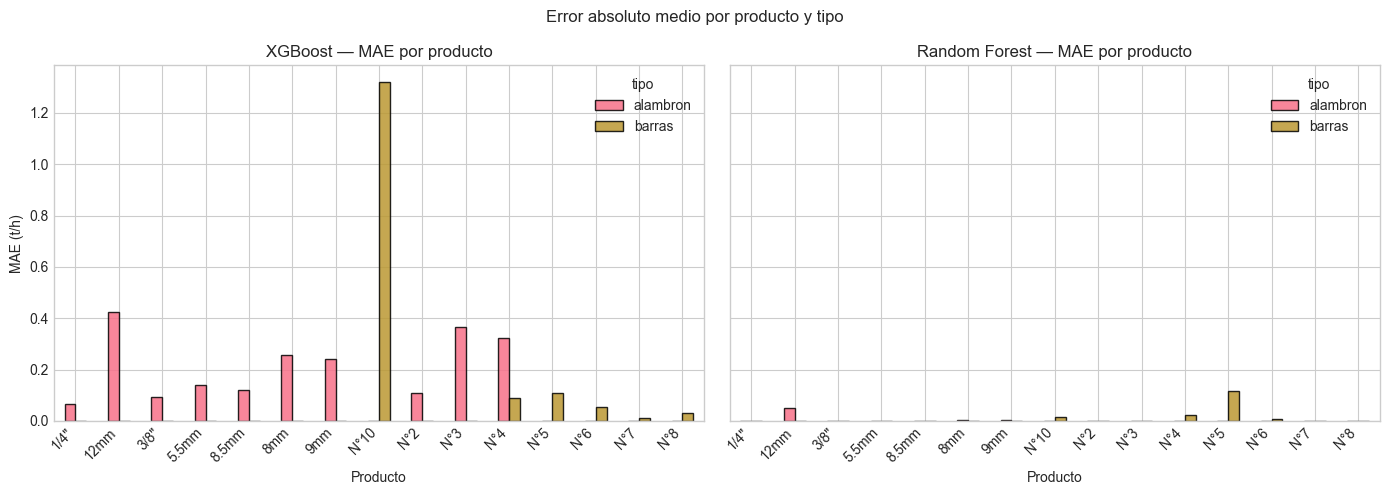

In [ ]:
res = X_test.copy()
res['real']     = y_test.values
res['err_xgb']  = np.abs(y_test.values - yp_xgb)
res['err_rf']   = np.abs(y_test.values - yp_rf)
res['producto'] = le_producto.inverse_transform(res['producto_cod'].astype(int))
res['tipo']     = res['tipo_cod'].map({0: 'alambron', 1: 'barras'})

err_p = res.groupby(['tipo', 'producto'])[['err_xgb', 'err_rf']].mean().round(3)
err_p.columns = ['MAE XGBoost', 'MAE RF']
print(err_p.sort_values('MAE XGBoost', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, col, label, color in [
    (axes[0], 'MAE XGBoost', 'XGBoost', C_XGB),
    (axes[1], 'MAE RF',      'Random Forest', C_RF),
]:
    pivot = err_p[col].unstack(level='tipo', fill_value=0)
    pivot.plot(kind='bar', ax=ax, edgecolor='k', alpha=0.85)
    ax.set_title(f'{label} — MAE por producto')
    ax.set_xlabel('Producto'); ax.set_ylabel('MAE (t/h)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Error absoluto medio por producto y tipo', fontsize=12)
plt.tight_layout(); plt.show()

## 14. Modelo de planificación — ambos modelos

Solo features conocidas **antes** de iniciar la orden (sin paradas observadas).

In [ ]:

X_plan = df[FEATURES_PLAN]
y_plan = df[TARGET]
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_plan, y_plan, test_size=0.2, random_state=SEED
)

xgb_plan = xgb.XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    random_state=SEED, verbosity=0, n_jobs=-1,
)
xgb_plan.fit(X_tr_p, y_tr_p, eval_set=[(X_te_p, y_te_p)], verbose=False)

rf_plan = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=3,
    oob_score=True, random_state=SEED, n_jobs=-1,
)
rf_plan.fit(X_tr_p, y_tr_p)

plan_results = {}
for name, m in [('XGBoost', xgb_plan), ('Random Forest', rf_plan)]:
    yp = m.predict(X_te_p)
    plan_results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_te_p, yp)),
        'MAE':  mean_absolute_error(y_te_p, yp),
        'R²':   r2_score(y_te_p, yp),
    }

plan_df = pd.DataFrame(plan_results).T.round(4)
print("=== Modelo solo planificación ===")
print(plan_df)

# Tabla comparativa completo vs planificación
resumen = pd.DataFrame({
    ('XGBoost', 'Completo'):     {'RMSE': metricas.loc['XGBoost', 'RMSE (t/h)'],
                                   'R²':   metricas.loc['XGBoost', 'R²']},
    ('XGBoost', 'Planif.'):      plan_results['XGBoost'],
    ('RF', 'Completo'):          {'RMSE': metricas.loc['Random Forest', 'RMSE (t/h)'],
                                   'R²':   metricas.loc['Random Forest', 'R²']},
    ('RF', 'Planif.'):           plan_results['Random Forest'],
}).T[['RMSE', 'R²']].round(4)
print("\n=== Completo vs. solo planificación ===")
print(resumen)


=== Modelo solo planificación ===
                 RMSE     MAE      R²
XGBoost        0.3297  0.1077  0.9998
Random Forest  0.0289  0.0073  1.0000

=== Completo vs. solo planificación ===
                    RMSE      R²
XGBoost Completo  0.5557  0.9994
        Planif.   0.3297  0.9998
RF      Completo  0.0498  1.0000
        Planif.   0.0289  1.0000


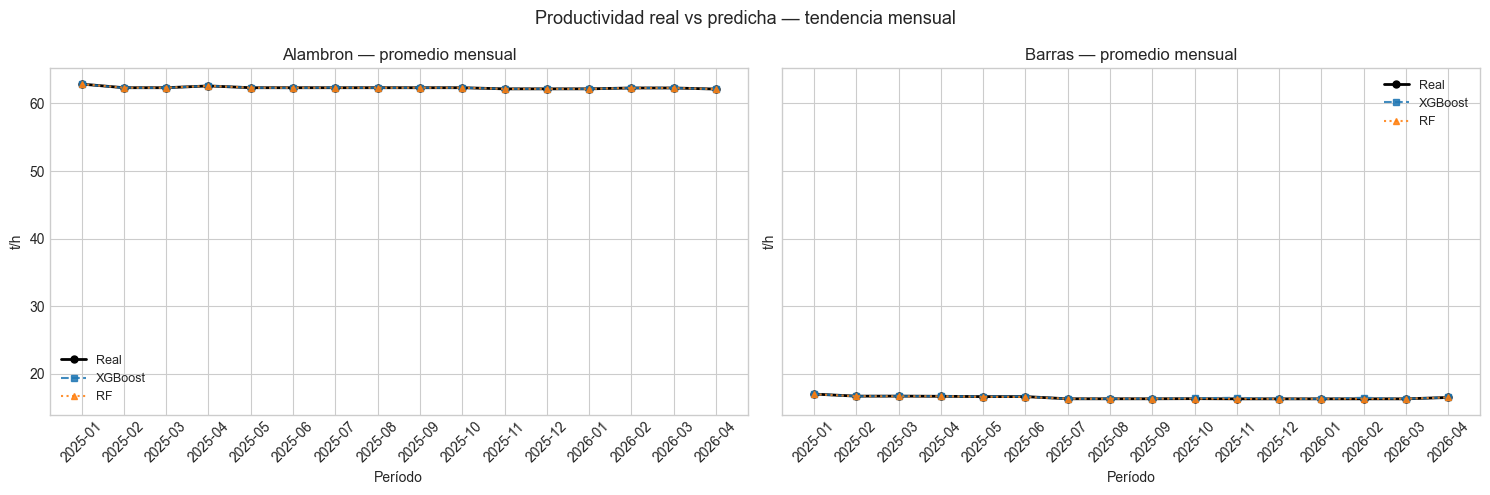

In [ ]:
# Tendencia mensual: real vs predicho de ambos modelos
yp_xgb_all = xgb_model.predict(df[FEATURES_ALL])
yp_rf_all  = rf_model.predict(df[FEATURES_ALL])

df_t = df[['mes_num', 'anio', TARGET, 'tipo_cod']].copy()
df_t['xgb'] = yp_xgb_all
df_t['rf']  = yp_rf_all

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, tipo_cod, label in [(axes[0], 0, 'Alambron'), (axes[1], 1, 'Barras')]:
    sub = df_t[df_t['tipo_cod'] == tipo_cod].copy()
    sub['periodo'] = (sub['anio'].astype(str) + '-' +
                      sub['mes_num'].astype(str).str.zfill(2))
    grp = sub.groupby('periodo')[[TARGET, 'xgb', 'rf']].mean()

    ax.plot(grp.index, grp[TARGET], 'o-k',  label='Real',   linewidth=2, markersize=5)
    ax.plot(grp.index, grp['xgb'],  's--',  label='XGBoost',
            color=C_XGB, linewidth=1.5, markersize=4, alpha=0.85)
    ax.plot(grp.index, grp['rf'],   '^:',   label='RF',
            color=C_RF,  linewidth=1.5, markersize=4, alpha=0.85)
    ax.set_title(f'{label} — promedio mensual')
    ax.set_xlabel('Período')
    ax.set_ylabel('t/h')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

plt.suptitle('Productividad real vs predicha — tendencia mensual', fontsize=13)
plt.tight_layout(); plt.show()